In [1]:
import numpy as np
import statsmodels.formula.api as smf
import utils.database as db
import utils.model_evaluation as me
import seaborn as sns

# Explore distribution of target variable

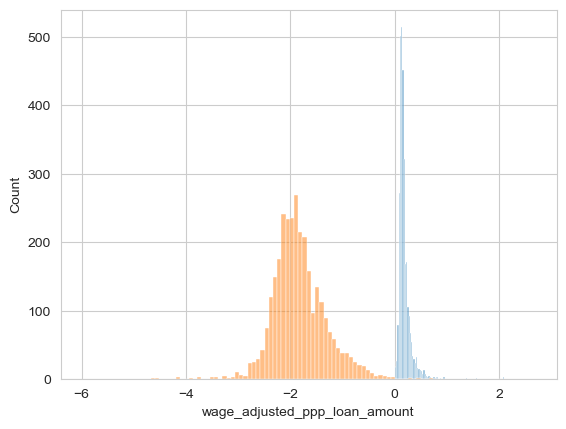

In [2]:
target = 'wage_adjusted_ppp_loan_amount'

query = """
    SELECT * EXCLUDE (ppp_loan_amount, total_annual_wages)
    FROM gold.wage_adjusted_ppp_target
"""
df = db.query_df(query)
g = sns.histplot(df[target], alpha=0.5, label='Original target')
g = sns.histplot(np.log(df[target]), alpha=0.5, label='Natural log transformed target')

## Evaluate correlations of numerical variables

Exclude all location quotient information for direct covariance with wage share. Keep wage share to prefer trends in local economic makeup, rather than relation to national economy indicated by loc quotient. 

In [3]:
numeric_features = df.select_dtypes(include='number')
numeric_features

,yoy_job_change_pct,wage_adjusted_ppp_loan_amount,white_pop_share,black_pop_share,asian_pop_share,native_pop_share,hispanic_share,trump_share,construction_wage_share,education_and_health_services_wage_share,financial_activities_wage_share,information_wage_share,leisure_and_hospitality_wage_share,manufacturing_wage_share,natural_resources_and_mining_wage_share,other_services_wage_share,professional_and_business_services_wage_share,trade_transportation_and_utilities_wage_share,unclassified_wage_share
0,0.014469,0.134846,0.429861,0.545240,0.006464,0.004650,0.027755,0.436560,0.040467,0.142572,0.044156,0.003321,0.102798,0.211594,0.016733,0.033681,0.068051,0.336627,0.000000
1,-0.044266,0.037927,0.679362,0.003543,0.015943,0.256864,0.123118,0.360465,0.000000,0.027200,0.070794,0.000000,0.665961,0.000000,0.000000,0.000000,0.203107,0.032939,0.000000
2,0.014401,0.111890,0.893100,0.013195,0.016451,0.037261,0.120502,0.584094,0.097230,0.100668,0.000000,0.000000,0.489495,0.035766,0.011409,0.060554,0.086602,0.118276,0.000000
3,0.056234,0.010167,0.901242,0.021268,0.008318,0.042325,0.476521,0.578593,0.142302,0.000000,0.008590,0.000000,0.058453,0.000000,0.000000,0.000000,0.099529,0.691126,0.000000
4,0.002028,0.118678,0.503822,0.009998,0.006239,0.458386,0.114871,0.510672,0.071208,0.353621,0.034578,0.019506,0.110763,0.018187,0.075879,0.018258,0.081401,0.216522,0.000077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3097,0.020850,0.172063,0.938790,0.018422,0.008843,0.016310,0.099578,0.479200,0.168985,0.088653,0.085514,0.017825,0.223447,0.031320,0.007410,0.034669,0.091520,0.250656,0.000000
3098,-0.002961,0.160525,0.932614,0.024105,0.021621,0.004209,0.070980,0.544437,0.105229,0.235182,0.041756,0.011434,0.058131,0.228191,0.008625,0.034198,0.099257,0.177445,0.000551
3099,-0.013008,0.158461,0.886127,0.039490,0.050484,0.003510,0.058791,0.441646,0.111089,0.260171,0.069902,0.028821,0.087850,0.000000,0.000000,0.057133,0.120159,0.263993,0.000883
3100,0.050093,0.263459,0.965466,0.006188,0.005390,0.011678,0.251322,0.803590,0.158492,0.064764,0.068105,0.010566,0.029515,0.026117,0.341134,0.033796,0.041617,0.225893,0.000000


Residuals vs. fitted for wage_adjusted_ppp_loan_amount


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                       0.0020791
Method:                                     IRLS   Log-Likelihood:                 5178.2
Date:                           Wed, 30 Jul 2025   Deviance:                       6.4452
Time:                                   07:54:12   Pearson chi2:                     6.45
No. Iterations:                                3   Pseudo R-squ. (CS):             0.9999
Covariance Type:                       nonrobust                                         
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -0.2776      0.003    -97.408      0.000      -0.283      -0.272
np.sqrt(wage_adjusted_ppp_loan_amount)     1.1211      0.007    170.586      0.000       1.108       1.134
==========================================================================================================
"""

bp_stat: 376.7767330623714 | bp_pvalue: 6.262170336555056e-84


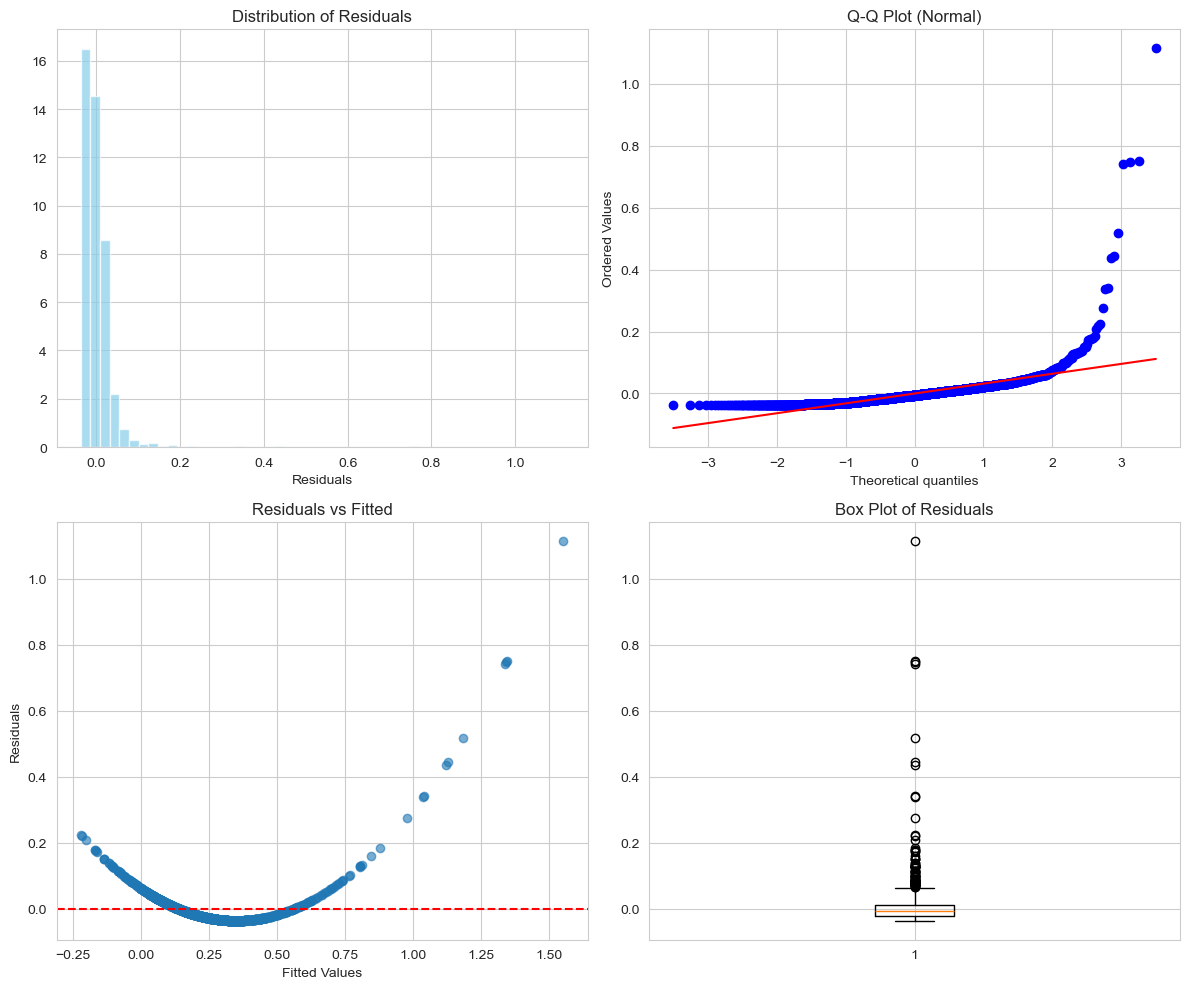

Residuals vs. fitted for construction_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.021379
Method:                                     IRLS   Log-Likelihood:                 1563.6
Date:                           Wed, 30 Jul 2025   Deviance:                       66.273
Time:                                   07:54:12   Pearson chi2:                     66.3
No. Iterations:                                3   Pseudo R-squ. (CS):            0.01010
Covariance Type:                       nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.2190      0.006     35.856      0.000       0.207       0.231
np.sqrt(construction_wage_share)    -0.1257      0.022     -5.610      0.000      -0.170      -0.082
====================================================================================================
"""

bp_stat: 39.11776225252242 | bp_pvalue: 3.989974102354758e-10


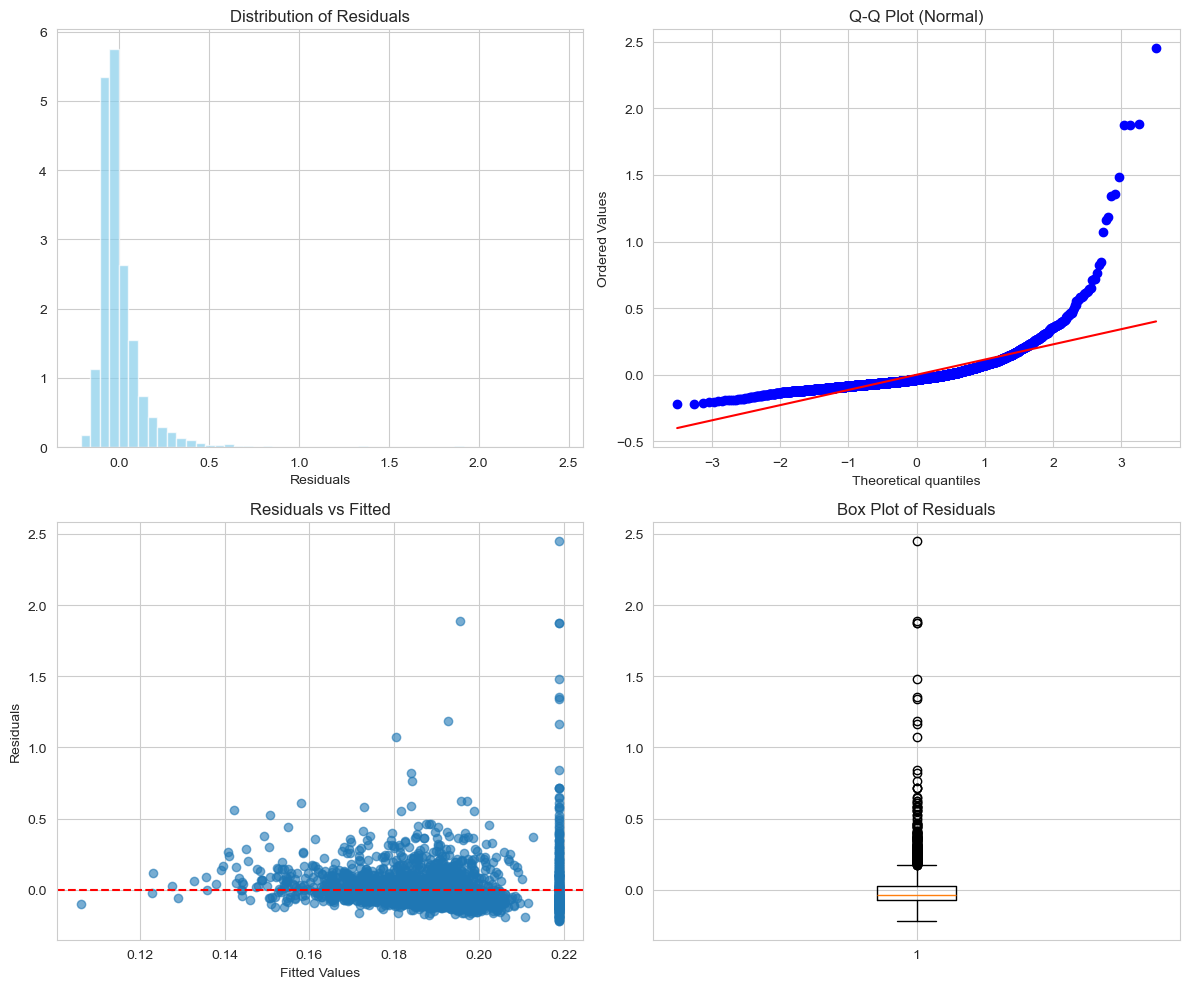

Residuals vs. fitted for education_and_health_services_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.021125
Method:                                     IRLS   Log-Likelihood:                 1582.1
Date:                           Wed, 30 Jul 2025   Deviance:                       65.489
Time:                                   07:54:13   Pearson chi2:                     65.5
No. Iterations:                                3   Pseudo R-squ. (CS):            0.02200
Covariance Type:                       nonrobust                                         
=====================================================================================================================
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             0.2510      0.008     31.318      0.000       0.235       0.267
np.sqrt(education_and_health_services_wage_share)    -0.1631      0.020     -8.306      0.000      -0.202      -0.125
=====================================================================================================================
"""

bp_stat: 19.643450689554967 | bp_pvalue: 9.332263317812267e-06


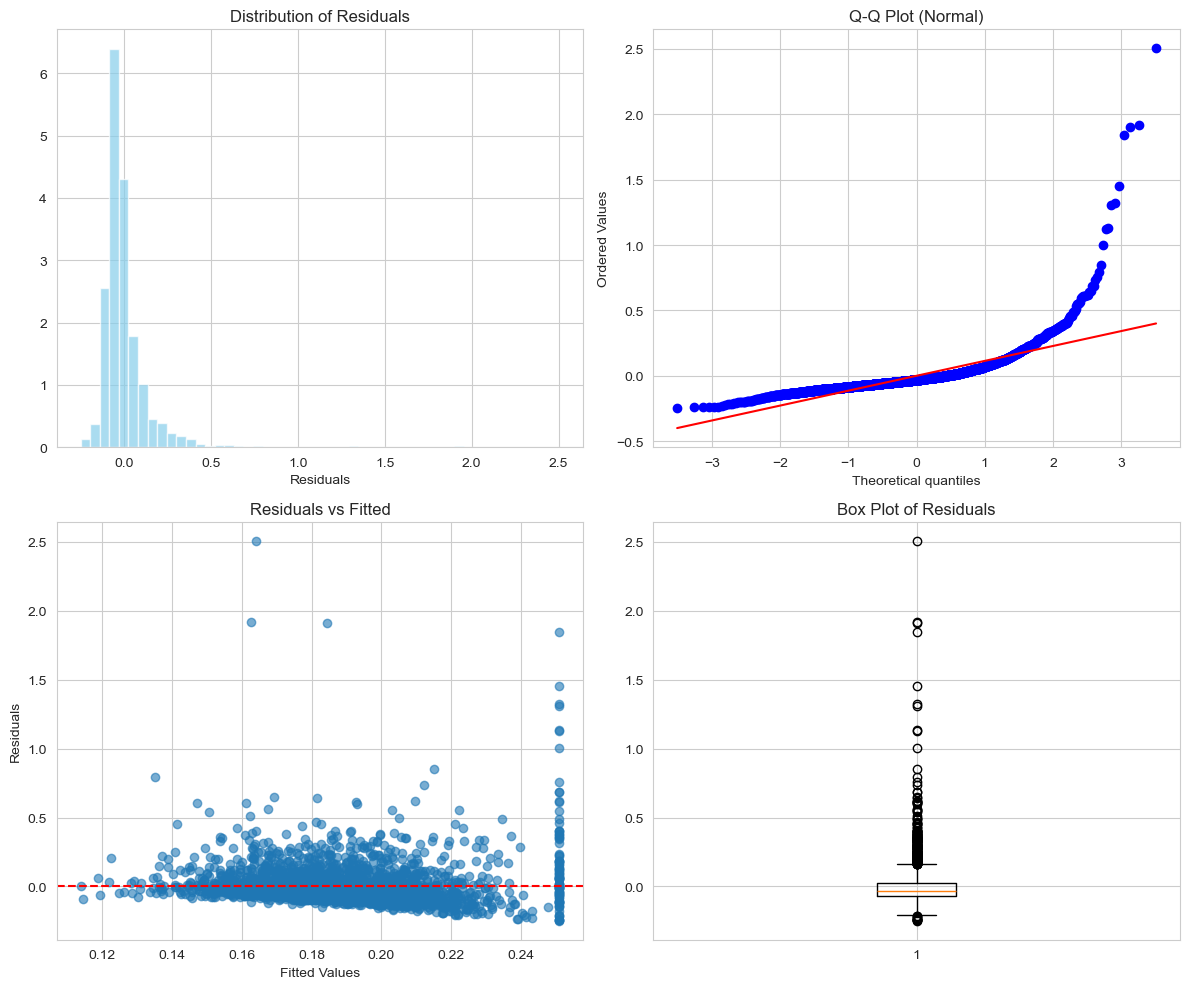

Residuals vs. fitted for financial_activities_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3101
Model:                                       GLM   Df Residuals:                     3099
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.020878
Method:                                     IRLS   Log-Likelihood:                 1599.8
Date:                           Wed, 30 Jul 2025   Deviance:                       64.702
Time:                                   07:54:13   Pearson chi2:                     64.7
No. Iterations:                                3   Pseudo R-squ. (CS):           0.005054
Covariance Type:                       nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    0.1600      0.007     21.492      0.000       0.145       0.175
np.sqrt(financial_activities_wage_share)     0.1196      0.030      3.964      0.000       0.060       0.179
============================================================================================================
"""

bp_stat: 24.781753963931536 | bp_pvalue: 6.420234176430024e-07


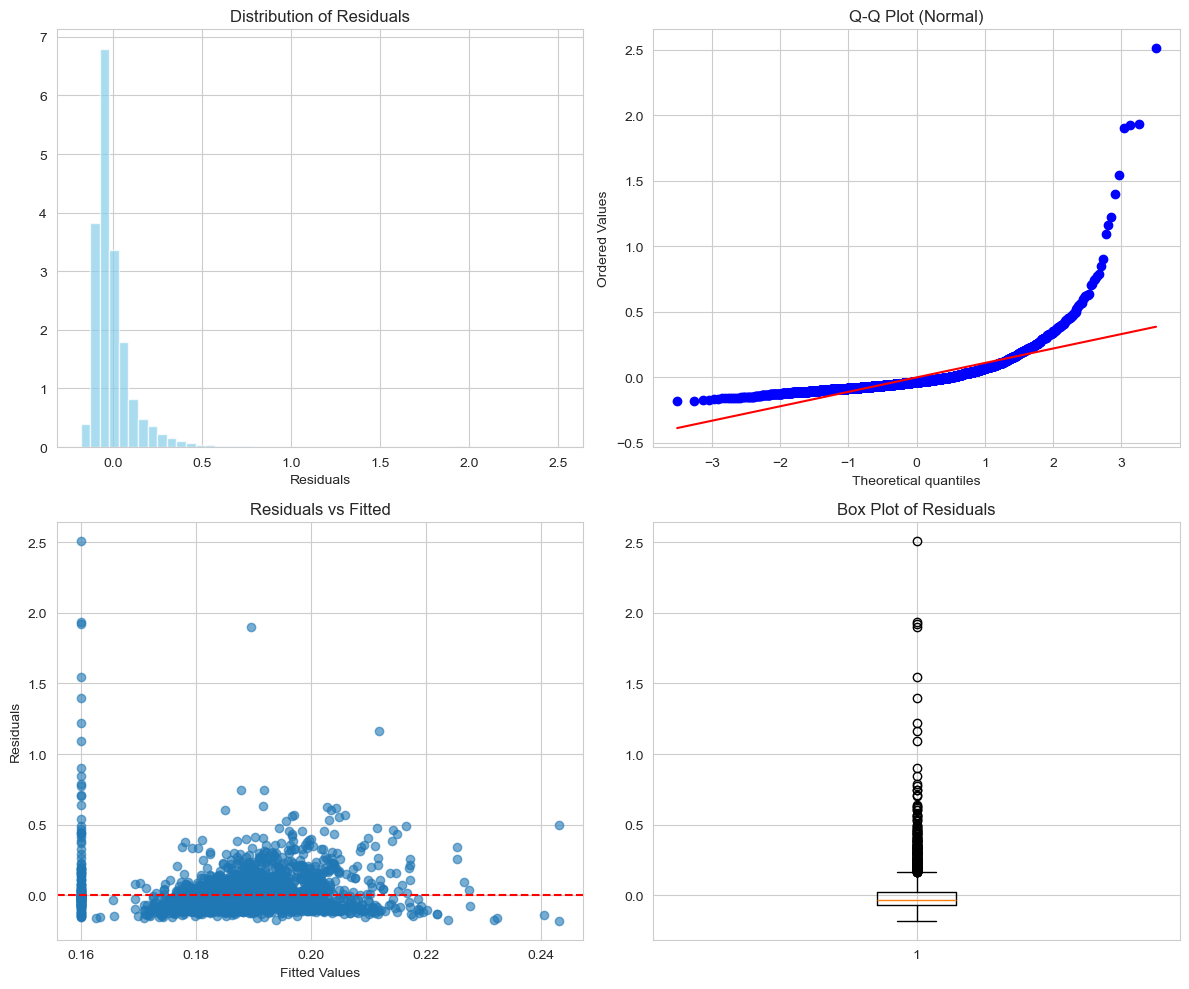

Residuals vs. fitted for information_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3101
Model:                                       GLM   Df Residuals:                     3099
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.019901
Method:                                     IRLS   Log-Likelihood:                 1674.1
Date:                           Wed, 30 Jul 2025   Deviance:                       61.675
Time:                                   07:54:13   Pearson chi2:                     61.7
No. Iterations:                                3   Pseudo R-squ. (CS):            0.05292
Covariance Type:                       nonrobust                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.2310      0.004     55.121      0.000       0.223       0.239
np.sqrt(information_wage_share)    -0.4977      0.038    -12.985      0.000      -0.573      -0.423
===================================================================================================
"""

bp_stat: 29.88478264389893 | bp_pvalue: 4.5849725930707354e-08


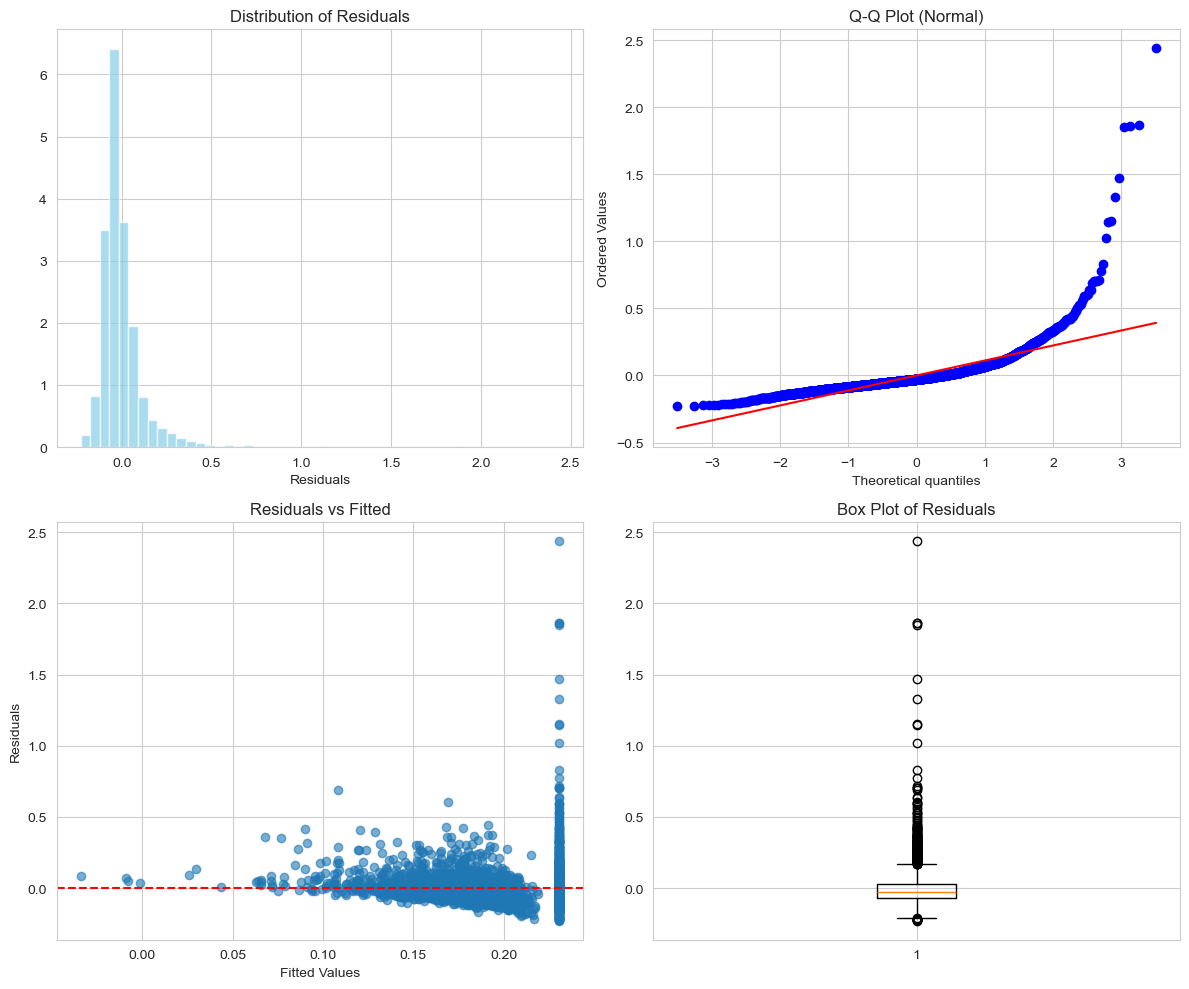

Residuals vs. fitted for leisure_and_hospitality_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.021522
Method:                                     IRLS   Log-Likelihood:                 1553.3
Date:                           Wed, 30 Jul 2025   Deviance:                       66.718
Time:                                   07:54:13   Pearson chi2:                     66.7
No. Iterations:                                3   Pseudo R-squ. (CS):           0.003419
Covariance Type:                       nonrobust                                         
===============================================================================================================
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                       0.2079      0.007     31.438      0.000       0.195       0.221
np.sqrt(leisure_and_hospitality_wage_share)    -0.0877      0.027     -3.259      0.001      -0.140      -0.035
===============================================================================================================
"""

bp_stat: 0.6833302678057358 | bp_pvalue: 0.408442311858666


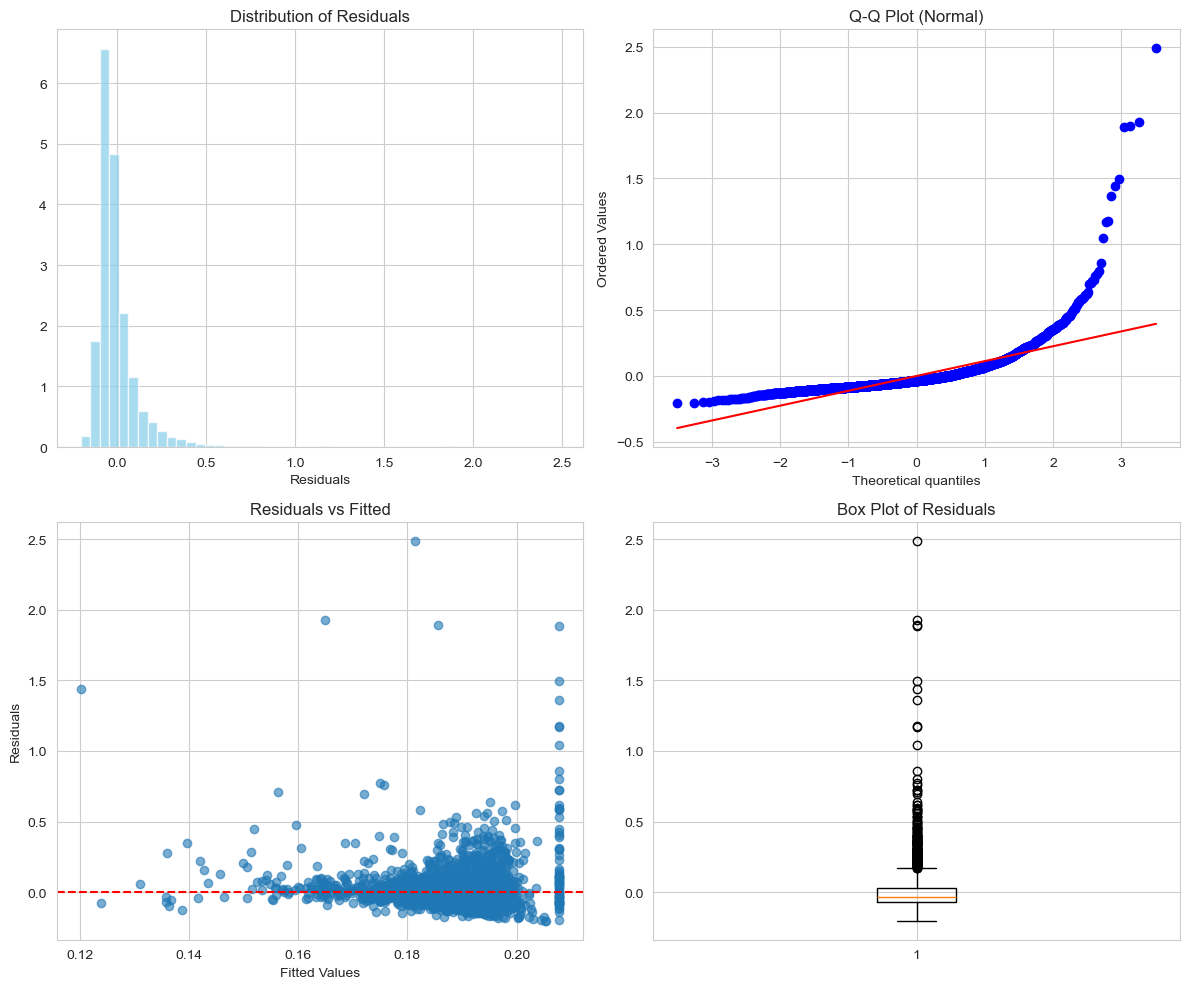

Residuals vs. fitted for manufacturing_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3101
Model:                                       GLM   Df Residuals:                     3099
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.019233
Method:                                     IRLS   Log-Likelihood:                 1727.1
Date:                           Wed, 30 Jul 2025   Deviance:                       59.603
Time:                                   07:54:14   Pearson chi2:                     59.6
No. Iterations:                                3   Pseudo R-squ. (CS):            0.08699
Covariance Type:                       nonrobust                                         
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.2621      0.005     51.551      0.000       0.252       0.272
np.sqrt(manufacturing_wage_share)    -0.1980      0.012    -16.799      0.000      -0.221      -0.175
=====================================================================================================
"""

bp_stat: 58.200900379532904 | bp_pvalue: 2.366707211692511e-14


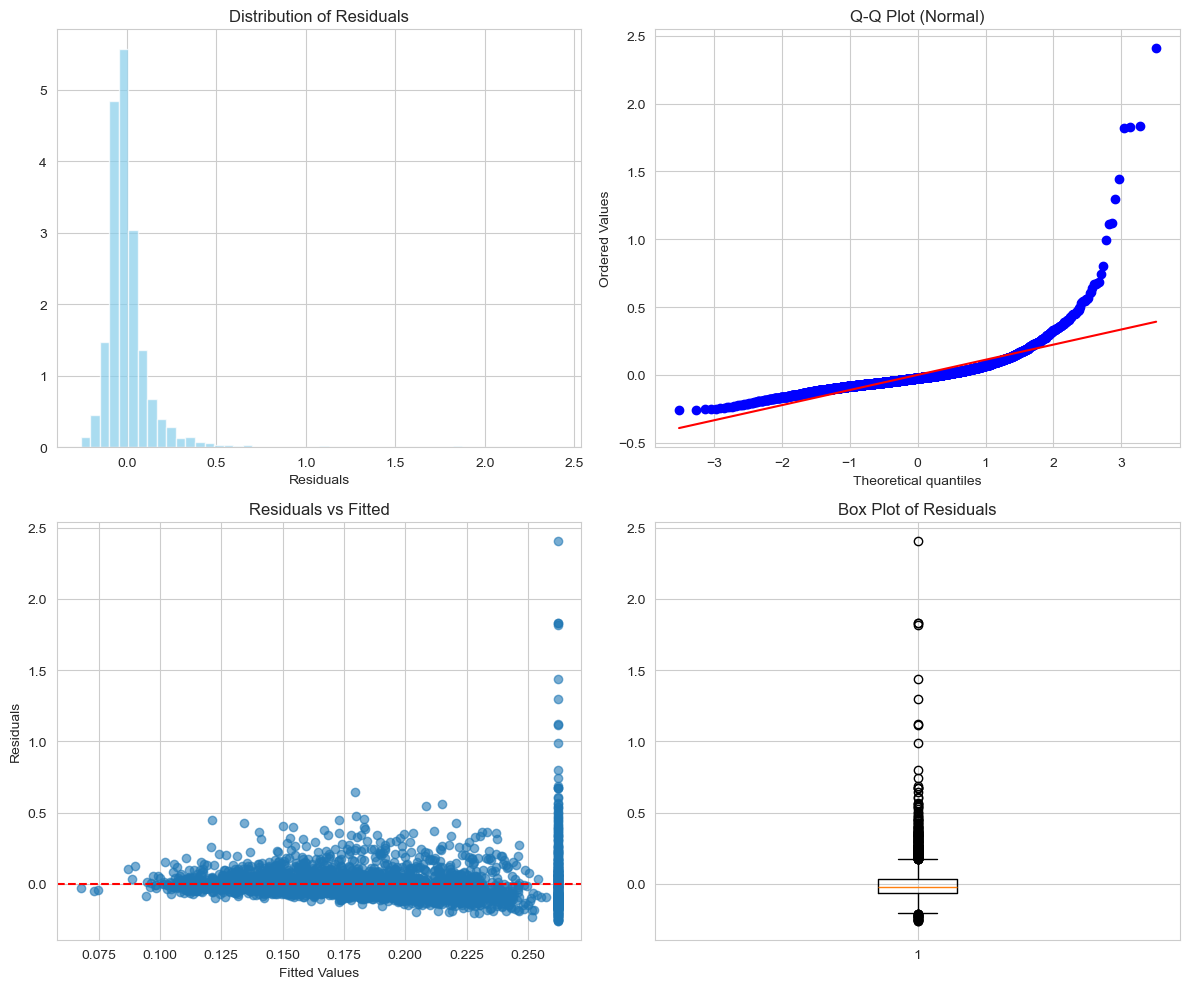

Residuals vs. fitted for natural_resources_and_mining_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.020582
Method:                                     IRLS   Log-Likelihood:                 1622.5
Date:                           Wed, 30 Jul 2025   Deviance:                       63.803
Time:                                   07:54:14   Pearson chi2:                     63.8
No. Iterations:                                3   Pseudo R-squ. (CS):            0.04805
Covariance Type:                       nonrobust                                         
====================================================================================================================
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                            0.1505      0.004     37.723      0.000       0.143       0.158
np.sqrt(natural_resources_and_mining_wage_share)     0.1800      0.015     12.359      0.000       0.151       0.208
====================================================================================================================
"""

bp_stat: 7.935812123586663 | bp_pvalue: 0.004846587036345719


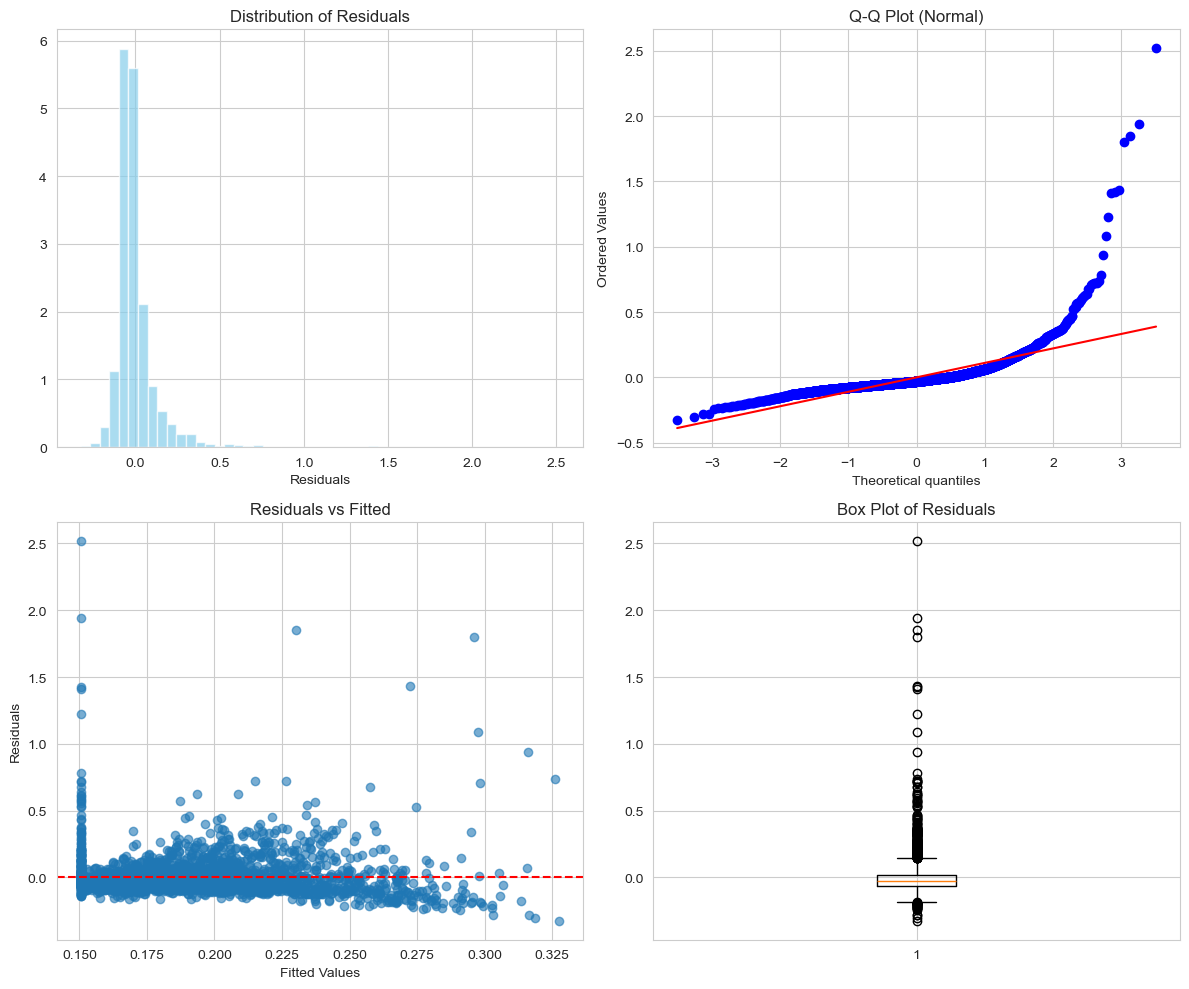

Residuals vs. fitted for other_services_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.021272
Method:                                     IRLS   Log-Likelihood:                 1571.3
Date:                           Wed, 30 Jul 2025   Deviance:                       65.945
Time:                                   07:54:14   Pearson chi2:                     65.9
No. Iterations:                                3   Pseudo R-squ. (CS):            0.01507
Covariance Type:                       nonrobust                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.2264      0.006     36.730      0.000       0.214       0.238
np.sqrt(other_services_wage_share)    -0.2780      0.041     -6.863      0.000      -0.357      -0.199
======================================================================================================
"""

bp_stat: 0.08597590232769359 | bp_pvalue: 0.769356690565018


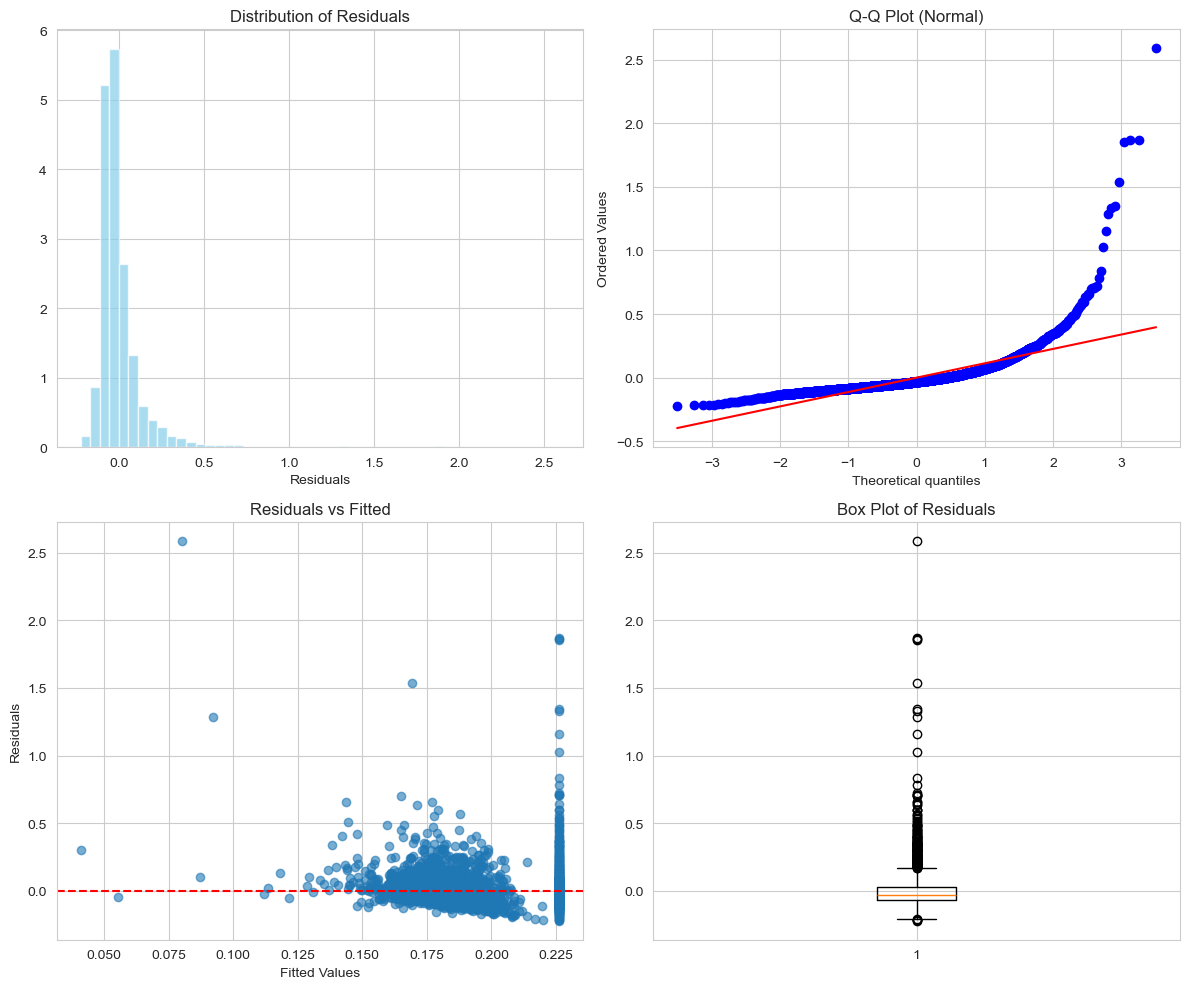

Residuals vs. fitted for professional_and_business_services_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3101
Model:                                       GLM   Df Residuals:                     3099
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.019126
Method:                                     IRLS   Log-Likelihood:                 1735.8
Date:                           Wed, 30 Jul 2025   Deviance:                       59.270
Time:                                   07:54:14   Pearson chi2:                     59.3
No. Iterations:                                3   Pseudo R-squ. (CS):            0.09256
Covariance Type:                       nonrobust                                         
==========================================================================================================================
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                  0.2870      0.006     45.988      0.000       0.275       0.299
np.sqrt(professional_and_business_services_wage_share)    -0.3457      0.020    -17.355      0.000      -0.385      -0.307
==========================================================================================================================
"""

bp_stat: 25.477767250911587 | bp_pvalue: 4.47510226693097e-07


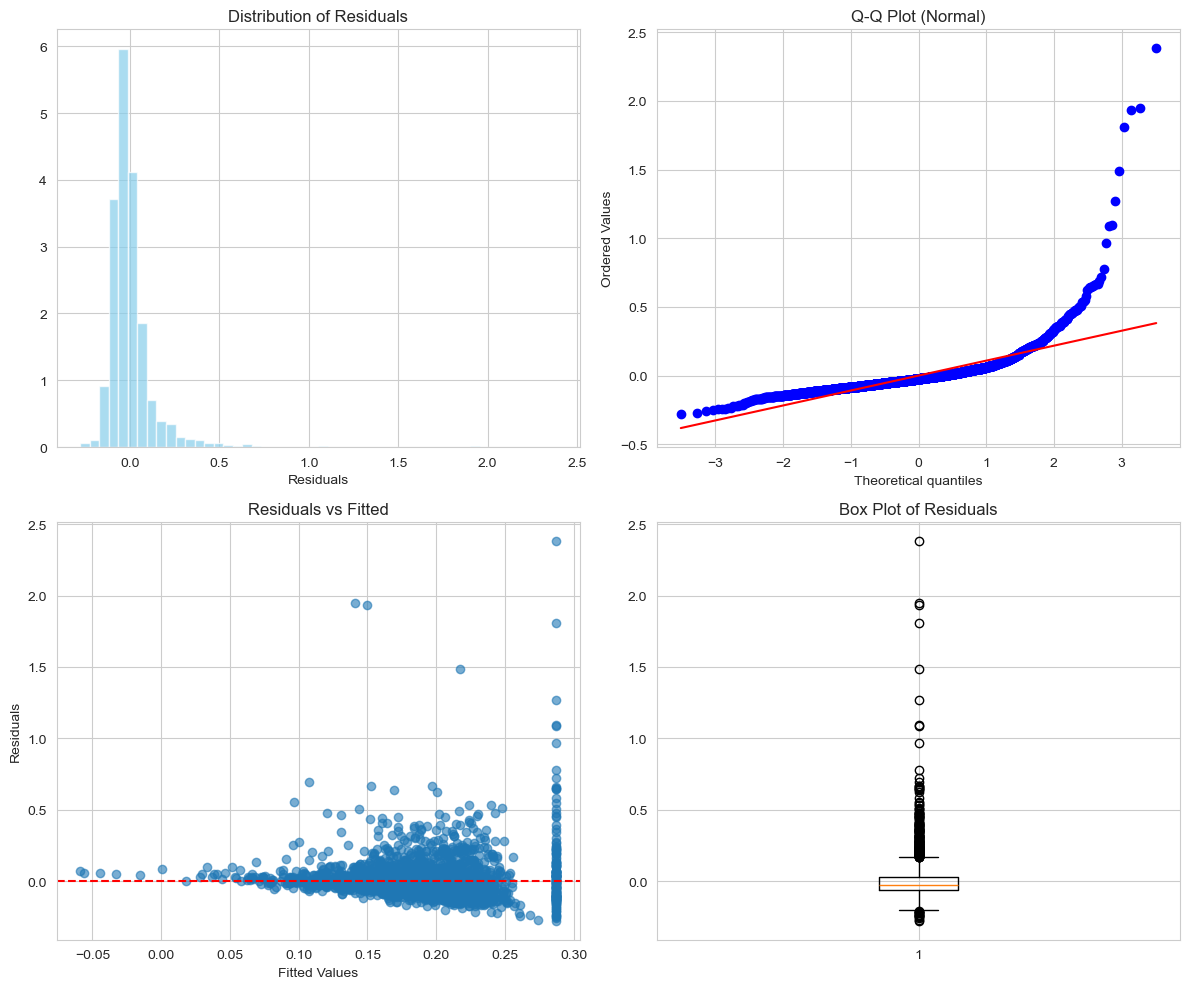

Residuals vs. fitted for trade_transportation_and_utilities_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3101
Model:                                       GLM   Df Residuals:                     3099
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.019138
Method:                                     IRLS   Log-Likelihood:                 1734.8
Date:                           Wed, 30 Jul 2025   Deviance:                       59.309
Time:                                   07:54:14   Pearson chi2:                     59.3
No. Iterations:                                3   Pseudo R-squ. (CS):            0.09191
Covariance Type:                       nonrobust                                         
==========================================================================================================================
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                 -0.0156      0.012     -1.295      0.195      -0.039       0.008
np.sqrt(trade_transportation_and_utilities_wage_share)     0.4214      0.024     17.291      0.000       0.374       0.469
==========================================================================================================================
"""

bp_stat: 11.400647587277819 | bp_pvalue: 0.0007341850827970579


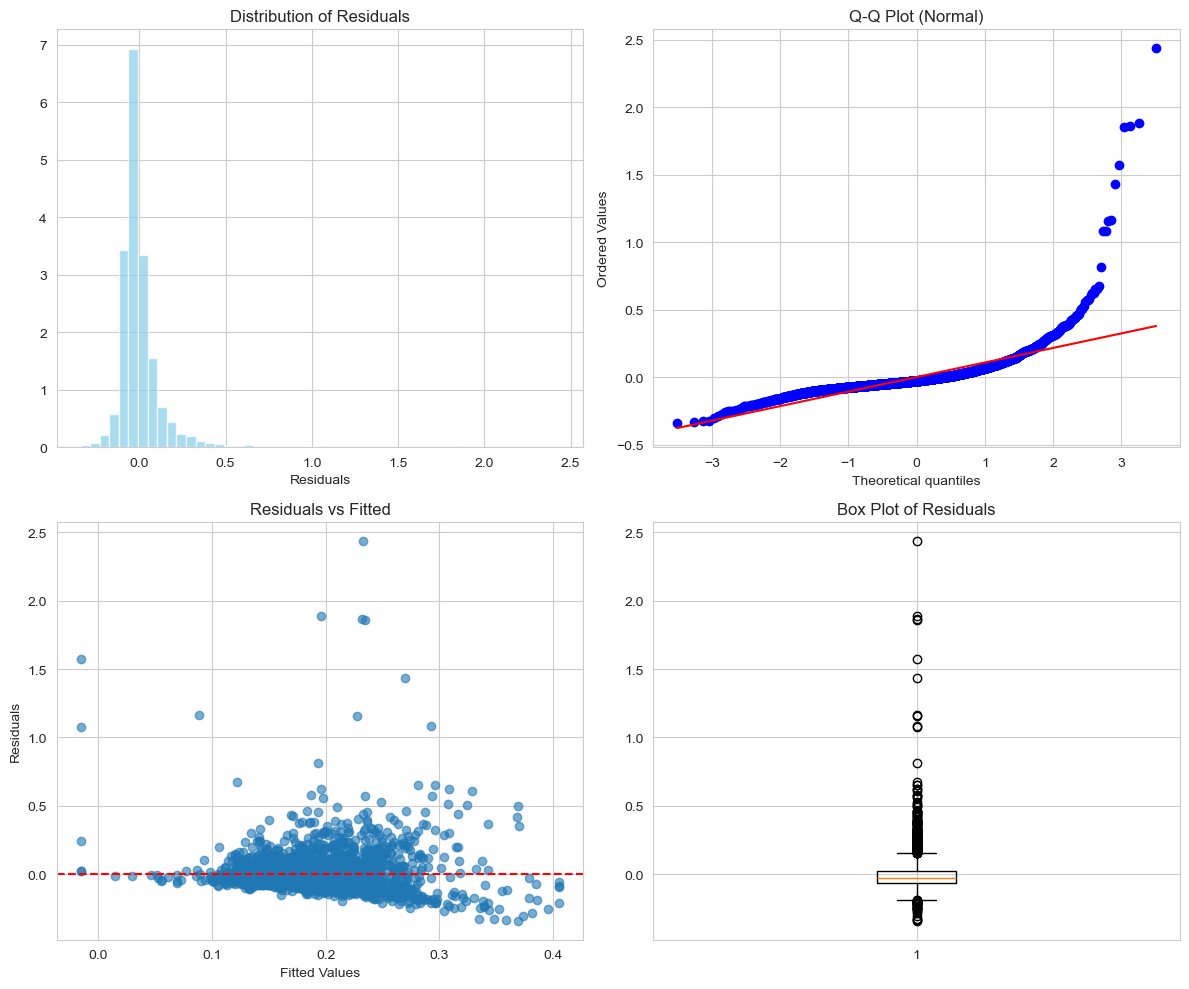

Residuals vs. fitted for unclassified_wage_share


<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3100
Model Family:                           Gaussian   Df Model:                            1
Link Function:                          Identity   Scale:                        0.021423
Method:                                     IRLS   Log-Likelihood:                 1560.4
Date:                           Wed, 30 Jul 2025   Deviance:                       66.412
Time:                                   07:54:15   Pearson chi2:                     66.4
No. Iterations:                                3   Pseudo R-squ. (CS):           0.008008
Covariance Type:                       nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.1943      0.003     66.800      0.000       0.189       0.200
np.sqrt(unclassified_wage_share)    -0.6455      0.129     -4.994      0.000      -0.899      -0.392
====================================================================================================
"""

bp_stat: 2.97575757917697 | bp_pvalue: 0.08452054738010331


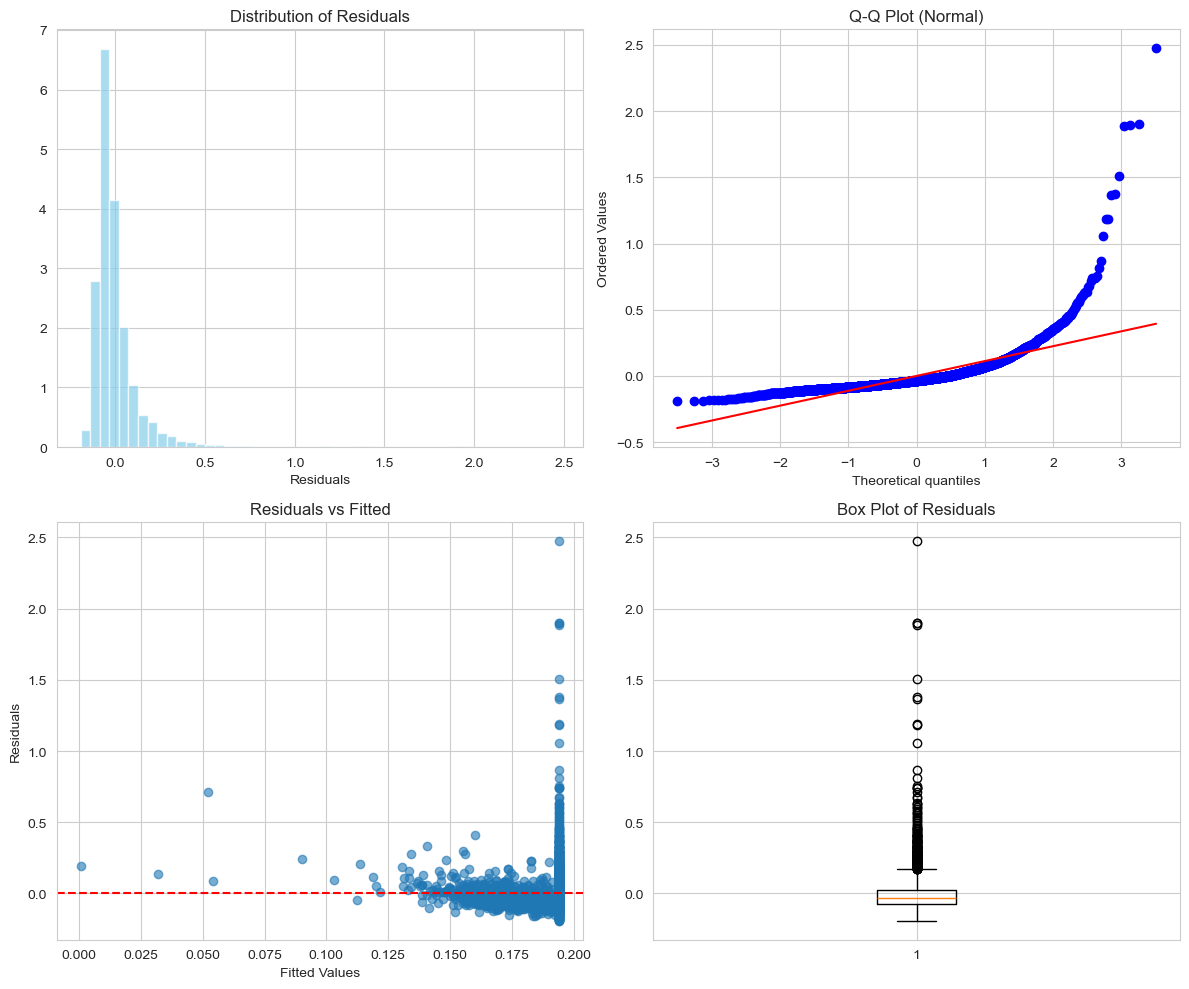

In [8]:
for feature in numeric_features:
    if 'wage' in feature:
        print(f'Residuals vs. fitted for {feature}')
        model = smf.glm(formula = f'{target} ~ np.sqrt({feature})', data = df).fit()
        display(model.summary())
        me.test_model_assumptions(model)

In [5]:
pred_df = df.copy()
pred_df['m_col_prediction'] = np.power(base_model.fittedvalues, 2)
g = sns.lmplot(x=f"{target}", y="m_col_prediction", data=pred_df)

NameError: name 'base_model' is not defined